# MASTER THESIS: Comparative Analysis of Anomaly Detection Methods for Real-Time Engine and OBD-II Vehicle Signal Monitoring
**Author:** Ashlo Shaju  
**Goal:** Evaluate Isolation Forest, LOF, One-Class SVM, and Autoencoder for real-time anomaly detection using a sliding-window simulation on vehicle telemetry data.

## 1. Environment Setup
Installing the Python Outlier Detection (`PyOD`) library, which provides a unified API for all four required algorithms.

In [24]:
# Install PyOD
!pip install pyod -q

## 2. Import Libraries & Load Dataset
In this section, we load the `vehicle_fault_dataset_smart.csv` file, parse the timestamps, and engineer our target anomaly label based on the `failure_type` column (No Failure = 0, any failure = 1).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# PyOD Models
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from pyod.models.auto_encoder import AutoEncoder

warnings.filterwarnings('ignore')

# 1. Load Dataset
df = pd.read_csv('vehicle_fault_dataset_smart.csv')

# 2. Parse Timestamp and Sort
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, format='mixed')
df = df.sort_values('timestamp').reset_index(drop=True)

# 3. Create Binary Target Label
df['is_anomaly'] = df['failure_type'].apply(lambda x: 0 if x == 'No Failure' else 1)

print(f"Dataset Loaded. Total Records: {df.shape[0]}")
print(f"Anomaly Distribution:\n{df['is_anomaly'].value_counts(normalize=True)*100}")
df.head()

Dataset Loaded. Total Records: 30000
Anomaly Distribution:
is_anomaly
0    66.553333
1    33.446667
Name: proportion, dtype: float64


,vehicle_id,brand,timestamp,odometer_reading,engine_temp_c,engine_rpm,oil_pressure_psi,coolant_temp_c,fuel_level_percent,fuel_consumption_lph,...,ambient_temp_c,humidity_percent,gps_latitude,gps_longitude,engine_failure_imminent,brake_issue_imminent,battery_issue_imminent,failure_date,failure_type,is_anomaly
0,VEH0000,Audi,2023-01-01 00:00:00,10000.0,99.233329,2652.708184,58.939125,91.998869,100.0,7.142203,...,13.172355,75.767116,-37.754568,144.995940,0,0,0,01/01/50 00:00,No Failure,0
1,VEH0000,Audi,2023-01-01 00:05:00,10000.5,91.772613,2060.971080,54.617212,89.541509,99.9,5.118227,...,33.177809,53.643182,-37.788936,145.013998,0,0,1,24/01/23 00:05,Battery Failure,1
2,VEH0000,Honda,2023-01-01 00:10:00,10001.0,70.383392,706.086291,33.974923,64.808222,99.8,1.044961,...,14.873139,33.527212,-37.745629,144.807616,0,0,1,23/01/23 00:10,Battery Failure,1
3,VEH0000,BMW,2023-01-01 00:15:00,10001.5,115.397735,2788.548824,56.691525,108.639143,99.7,8.819674,...,29.761678,41.747559,-37.869253,144.934894,0,0,0,01/01/50 00:00,No Failure,0
4,VEH0000,BMW,2023-01-01 00:20:00,10002.0,101.620302,1429.811781,43.528876,94.734269,99.6,6.003020,...,11.781224,36.905451,-37.732907,145.053844,0,0,1,29/01/23 00:20,Battery Failure,1


## Exploratory Data Analysis (EDA)
In this section, we generate 7 detailed visualizations to understand the behavior of the real-time vehicle engine and OBD-II signals, analyze the class imbalance, and investigate the statistical distributions of anomalies.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style for seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Define the core sensor columns to focus on
core_sensors =['engine_rpm', 'coolant_temp_c', 'engine_temp_c',
                'oil_pressure_psi', 'vehicle_speed_kph', 'throttle_pos_percent']

### Graph 1 & 2: Class Imbalance and Failure Type Breakdown
Anomalies in vehicle maintenance are typically rare. **Graph 1** shows the overall class distribution (Normal vs. Anomaly), and **Graph 2** breaks down the specific types of failures causing these anomalies.

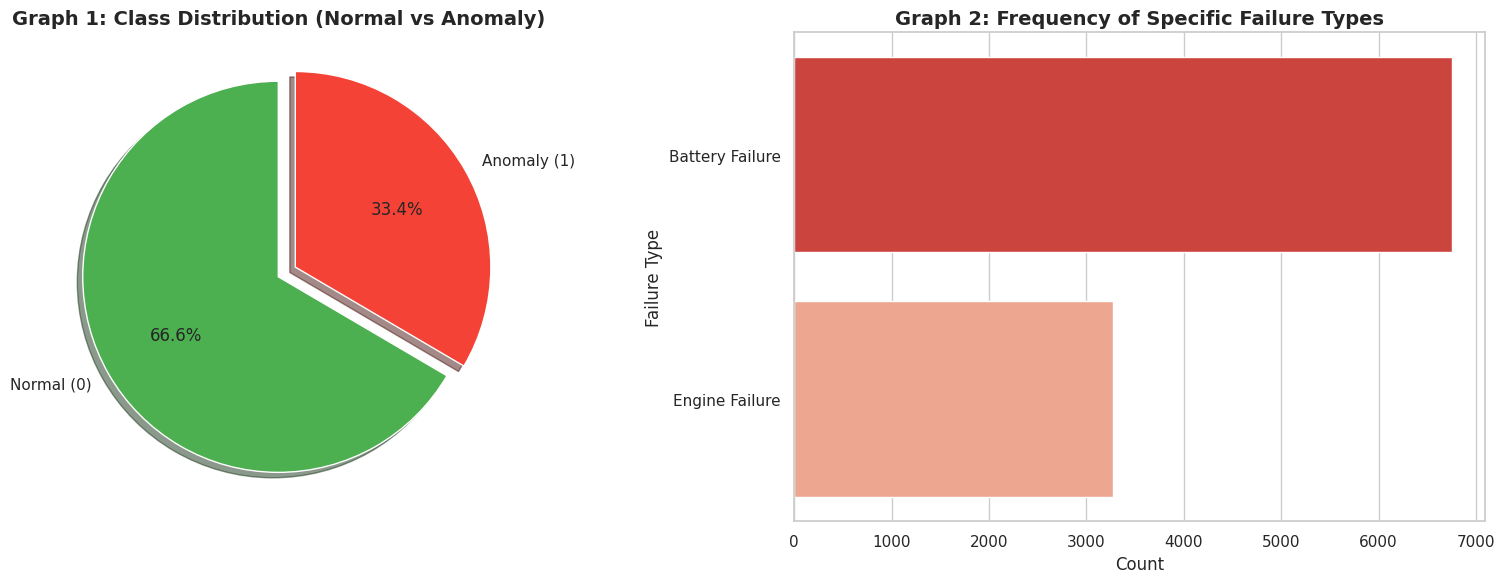

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Normal vs Anomaly Distribution (Pie Chart)
anomaly_counts = df['is_anomaly'].value_counts()
ax[0].pie(anomaly_counts, labels=['Normal (0)', 'Anomaly (1)'], autopct='%1.1f%%',
          startangle=90, colors=['#4CAF50', '#F44336'], explode=[0, 0.1], shadow=True)
ax[0].set_title('Graph 1: Class Distribution (Normal vs Anomaly)', fontsize=14, fontweight='bold')

# Graph 2: Breakdown of specific failure types
# Filter out 'No Failure' to just see the types of anomalies
failures_only = df[df['failure_type'] != 'No Failure']
sns.countplot(y='failure_type', data=failures_only, ax=ax[1],
              order=failures_only['failure_type'].value_counts().index, palette='Reds_r')
ax[1].set_title('Graph 2: Frequency of Specific Failure Types', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Count')
ax[1].set_ylabel('Failure Type')

plt.tight_layout()
plt.show()

### Graph 3: Correlation Heatmap of OBD-II Sensor Signals
This heatmap helps us understand the linear relationships between core engine signals. For example, `engine_rpm`, `throttle_pos_percent`, and `vehicle_speed_kph` should generally have a high positive correlation.

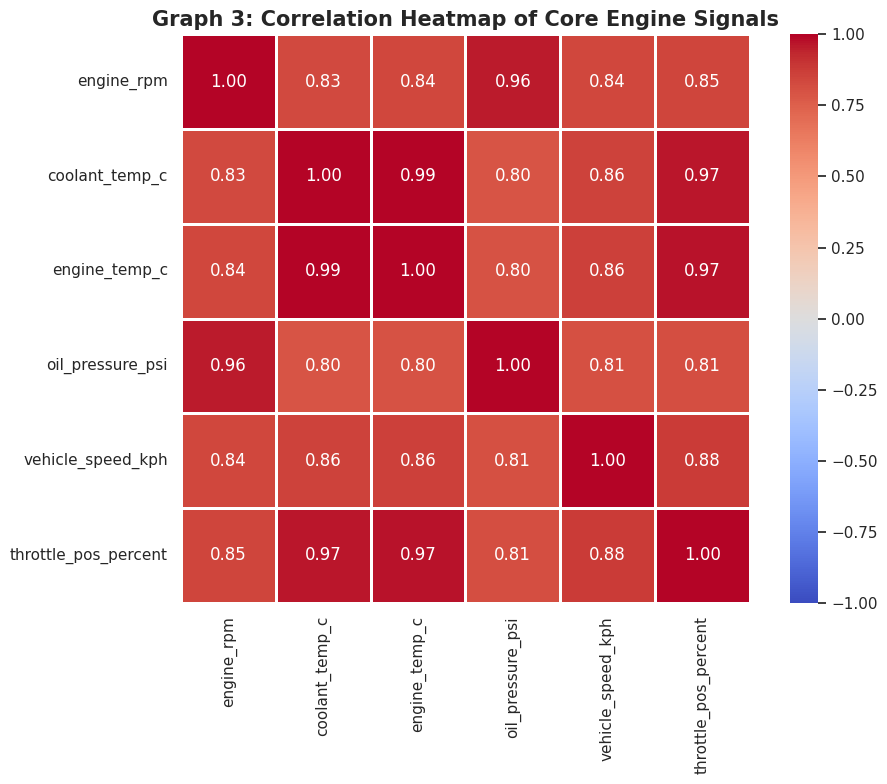

In [28]:
plt.figure(figsize=(10, 8))

# Calculate Pearson correlation matrix for core sensors
corr_matrix = df[core_sensors].corr()

# Graph 3: Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Graph 3: Correlation Heatmap of Core Engine Signals', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### Graph 4: Boxplots for Univariate Outlier Detection
Boxplots are excellent for classical anomaly detection. They visually demonstrate how the median and variance of sensor readings (like RPM and Temperature) shift when the vehicle experiences an anomaly compared to normal driving.

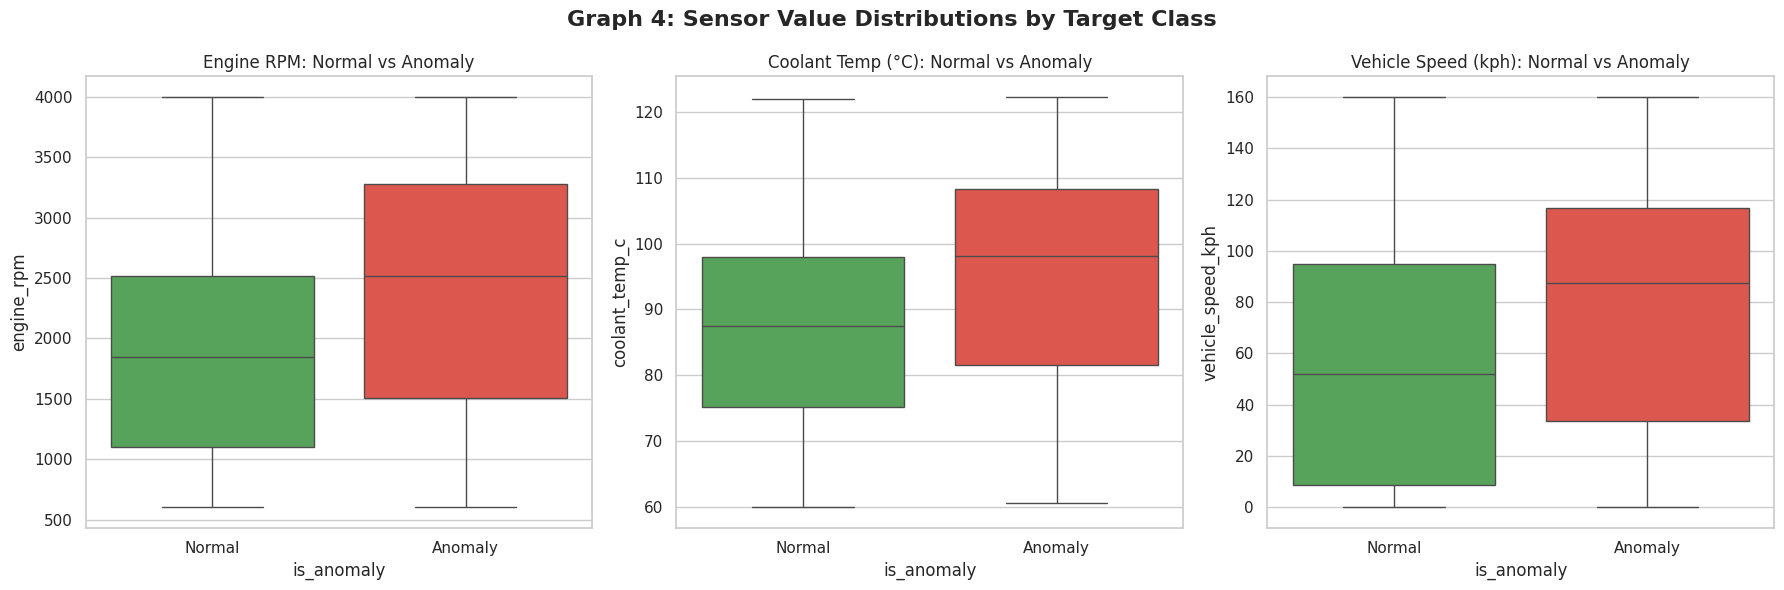

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Graph 4: Boxplots for RPM, Coolant Temp, and Vehicle Speed
sns.boxplot(x='is_anomaly', y='engine_rpm', data=df, ax=axes[0], palette=['#4CAF50', '#F44336'])
axes[0].set_title('Engine RPM: Normal vs Anomaly')
axes[0].set_xticklabels(['Normal', 'Anomaly'])

sns.boxplot(x='is_anomaly', y='coolant_temp_c', data=df, ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].set_title('Coolant Temp (°C): Normal vs Anomaly')
axes[1].set_xticklabels(['Normal', 'Anomaly'])

sns.boxplot(x='is_anomaly', y='vehicle_speed_kph', data=df, ax=axes[2], palette=['#4CAF50', '#F44336'])
axes[2].set_title('Vehicle Speed (kph): Normal vs Anomaly')
axes[2].set_xticklabels(['Normal', 'Anomaly'])

plt.suptitle('Graph 4: Sensor Value Distributions by Target Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Graph 5: KDE Density Plots (Probability Distributions)
Kernel Density Estimation (KDE) plots show the shape of the data distribution. We can see if anomalous data forms a distinct "second peak" (bimodal distribution) or resides in the long tails of the normal distribution.

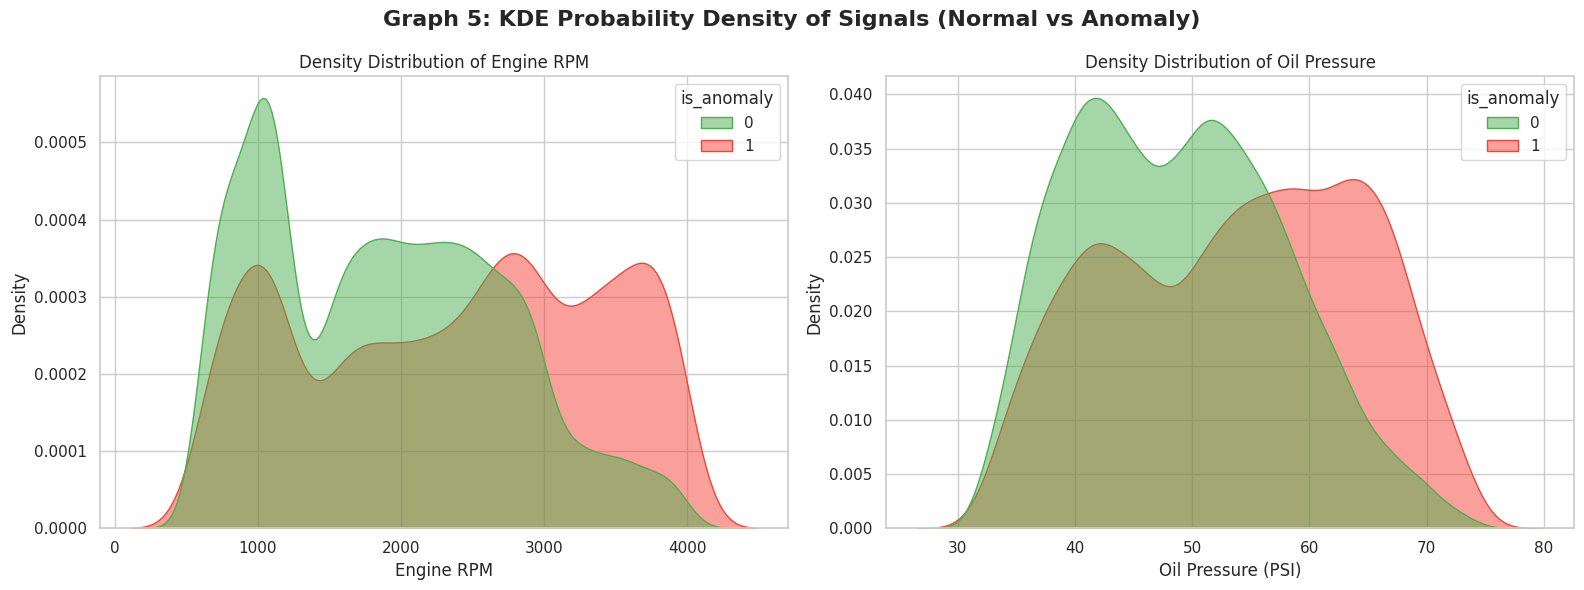

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 5: KDE Plots for RPM and Oil Pressure
sns.kdeplot(data=df, x='engine_rpm', hue='is_anomaly', fill=True, common_norm=False,
            palette=['#4CAF50', '#F44336'], ax=axes[0], alpha=0.5)
axes[0].set_title('Density Distribution of Engine RPM')
axes[0].set_xlabel('Engine RPM')

sns.kdeplot(data=df, x='oil_pressure_psi', hue='is_anomaly', fill=True, common_norm=False,
            palette=['#4CAF50', '#F44336'], ax=axes[1], alpha=0.5)
axes[1].set_title('Density Distribution of Oil Pressure')
axes[1].set_xlabel('Oil Pressure (PSI)')

plt.suptitle('Graph 5: KDE Probability Density of Signals (Normal vs Anomaly)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Graph 6: Multivariate Pairplot
A pairplot visualizes multi-dimensional relationships. By plotting multiple sensors against each other, we can observe if anomalies form distinct spatial clusters that algorithms like LOF or SVM can easily separate. *(Note: We use a random sample to prevent Colab from crashing due to high memory usage).*

# Graph 6: Pairplot of a subset of core features
# We sample 2000 rows to make the rendering fast and avoid Colab memory limits
sample_df = df.sample(n=min(2000, len(df)), random_state=42)

pairplot_features =['engine_rpm', 'coolant_temp_c', 'throttle_pos_percent', 'is_anomaly']

g = sns.pairplot(sample_df[pairplot_features], hue='is_anomaly', palette=['#4CAF50', '#F44336'],
                 diag_kind='hist', markers=["o", "x"], plot_kws={'alpha':0.6})

g.fig.suptitle('Graph 6: Multivariate Sensor Relationships', y=1.02, fontsize=16, fontweight='bold')
plt.show()

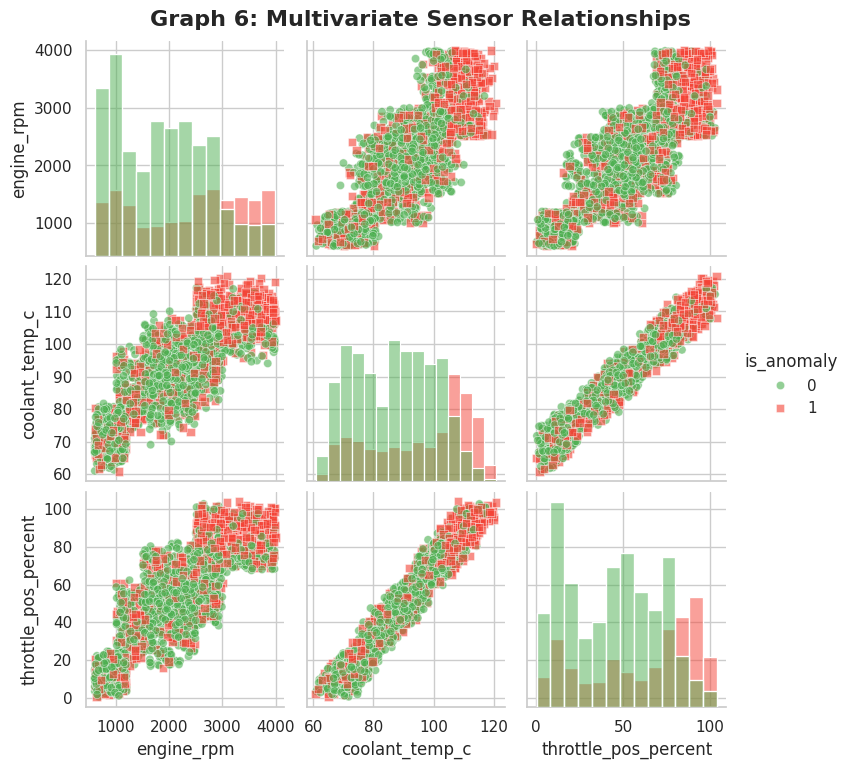

In [31]:
# Graph 6: Pairplot of a subset of core features
# We sample 2000 rows to make the rendering fast and avoid Colab memory limits
sample_df = df.sample(n=min(2000, len(df)), random_state=42)

pairplot_features =['engine_rpm', 'coolant_temp_c', 'throttle_pos_percent', 'is_anomaly']

# FIX: Changed markers to ["o", "s"] (circle and square)
# to avoid Seaborn's "filled and line art" mixing error.
g = sns.pairplot(sample_df[pairplot_features],
                 hue='is_anomaly',
                 palette=['#4CAF50', '#F44336'],
                 diag_kind='hist',
                 markers=["o", "s"],
                 plot_kws={'alpha':0.6})

g.fig.suptitle('Graph 6: Multivariate Sensor Relationships', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### Graph 7: Time-Series Signal Volatility
Because telemetry data is continuous, examining a sequential time window helps us observe the volatility of the signals and how anomalies manifest as sudden spikes or dips over time.

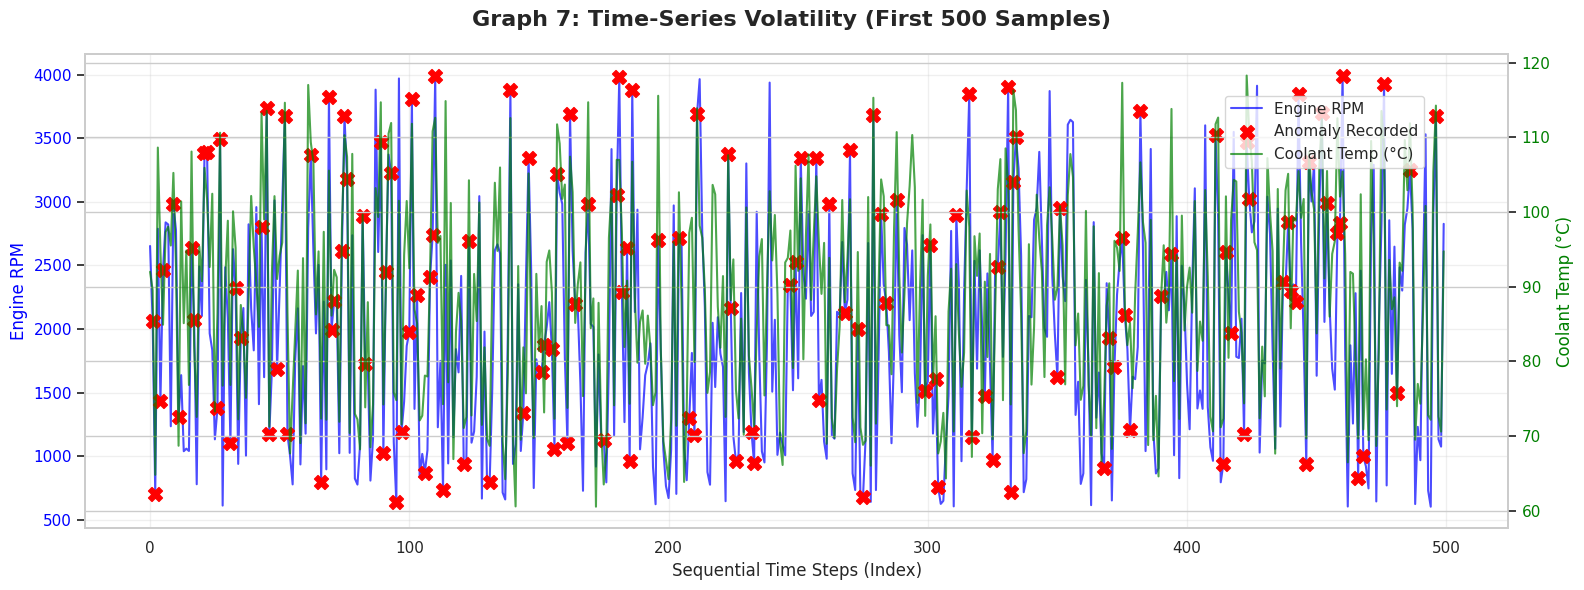

In [32]:
# Graph 7: Sequential plot of the first 500 records
time_window = df.head(500)

fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot Engine RPM on primary Y-axis
ax1.plot(time_window.index, time_window['engine_rpm'], color='blue', label='Engine RPM', alpha=0.7)
ax1.set_xlabel('Sequential Time Steps (Index)')
ax1.set_ylabel('Engine RPM', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary Y-axis for Coolant Temperature
ax2 = ax1.twinx()
ax2.plot(time_window.index, time_window['coolant_temp_c'], color='green', label='Coolant Temp (°C)', alpha=0.7)
ax2.set_ylabel('Coolant Temp (°C)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Highlight anomalous indices in this window
anomalies_in_window = time_window[time_window['is_anomaly'] == 1]
if not anomalies_in_window.empty:
    ax1.scatter(anomalies_in_window.index, anomalies_in_window['engine_rpm'],
                color='red', label='Anomaly Recorded', marker='X', s=100, zorder=5)

fig.suptitle('Graph 7: Time-Series Volatility (First 500 Samples)', fontsize=16, fontweight='bold')
ax1.grid(alpha=0.3)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))

plt.tight_layout()
plt.show()

## 3. Sliding-Window Segmentation & Feature Preprocessing
To simulate real-time streaming (Task 3), we calculate rolling means and standard deviations. We then split the data chronologically to prevent data leakage and apply `StandardScaler`.

In [33]:
# Define critical signals mentioned in the proposal
sensor_cols =[
    'engine_rpm', 'coolant_temp_c', 'engine_temp_c',
    'oil_pressure_psi', 'vehicle_speed_kph', 'throttle_pos_percent'
]

# Apply Sliding-Window Feature Engineering (Window size = 5 intervals)
window_size = 5
for col in sensor_cols:
    df[f'{col}_roll_mean'] = df[col].rolling(window=window_size, min_periods=1).mean()
    df[f'{col}_roll_std'] = df[col].rolling(window=window_size, min_periods=1).std().fillna(0)

# Define final features
features = sensor_cols +[f'{col}_roll_mean' for col in sensor_cols] + [f'{col}_roll_std' for col in sensor_cols]

X = df[features]
y = df['is_anomaly']

# Train-Test Split (Chronological: 70% Train, 30% Test)
split_idx = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_timestamps = df['timestamp'].iloc[split_idx:]

# Normalize Features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Global dictionaries to store model results
results = {}
predictions = {}
decision_scores = {}

# Calculate expected contamination (anomaly ratio)
contamination_rate = sum(y_train) / len(y_train)
# If no anomalies in train, set a default small contamination rate for PyOD models
if contamination_rate == 0:
    contamination_rate = 0.05

print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")
print(f"Contamination Rate: {contamination_rate:.4f}")

Training set: (21000, 18)
Testing set: (9000, 18)
Contamination Rate: 0.3345


## 4. Model 1: Isolation Forest
Isolation forest uses tree-based partitioning to isolate anomalies. We train the model and predict on the test set.

In [34]:
print("--- Training Isolation Forest ---")
model_name = "Isolation Forest"

# Initialize and track time
start_time = time.time()
iforest = IForest(contamination=contamination_rate, random_state=42)
iforest.fit(X_train_scaled)

# Prediction and Scoring
y_pred = iforest.predict(X_test_scaled)
y_scores = iforest.decision_function(X_test_scaled)
processing_time = time.time() - start_time

# Store Metrics
results[model_name] = {
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_scores),
    'Time (s)': processing_time
}
predictions[model_name] = y_pred
decision_scores[model_name] = y_scores

print(f"Done! Processing Time: {processing_time:.4f} seconds")

--- Training Isolation Forest ---
Done! Processing Time: 1.6464 seconds


## 5. Model 2: Local Outlier Factor (LOF)
LOF relies on local density estimation. It flags data points that have a substantially lower density than their neighbors.

In [35]:
# Define critical signals mentioned in the proposal
sensor_cols =[
    'engine_rpm', 'coolant_temp_c', 'engine_temp_c',
    'oil_pressure_psi', 'vehicle_speed_kph', 'throttle_pos_percent'
]

# --- NEW: Handle Missing Values ---
# Forward-fill (carries the last valid observation forward) and
# Backward-fill (for any NaNs at the very beginning)
df[sensor_cols] = df[sensor_cols].ffill().bfill()

# Apply Sliding-Window Feature Engineering (Window size = 5 intervals)
window_size = 5
for col in sensor_cols:
    df[f'{col}_roll_mean'] = df[col].rolling(window=window_size, min_periods=1).mean()
    df[f'{col}_roll_std'] = df[col].rolling(window=window_size, min_periods=1).std().fillna(0)

# Define final features
features = sensor_cols +[f'{col}_roll_mean' for col in sensor_cols] + [f'{col}_roll_std' for col in sensor_cols]

X = df[features]
y = df['is_anomaly']

# Train-Test Split (Chronological: 70% Train, 30% Test)
split_idx = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
test_timestamps = df['timestamp'].iloc[split_idx:]

# Normalize Features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Global dictionaries to store model results
results = {}
predictions = {}
decision_scores = {}

# Calculate expected contamination (anomaly ratio)
contamination_rate = sum(y_train) / len(y_train)
# If no anomalies in train, set a default small contamination rate for PyOD models
if contamination_rate == 0:
    contamination_rate = 0.05

print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")
print(f"Contamination Rate: {contamination_rate:.4f}")
print("Missing values handled successfully. Ready for LOF!")

Training set: (21000, 18)
Testing set: (9000, 18)
Contamination Rate: 0.3345
Missing values handled successfully. Ready for LOF!


## 6. Model 3: One-Class SVM
One-Class SVM defines a hypersphere boundary around normal data. Anything outside is classified as an anomaly.

In [36]:
print("--- Training One-Class SVM ---")
model_name = "One-Class SVM"

start_time = time.time()
ocsvm = OCSVM(contamination=contamination_rate, kernel='rbf')
ocsvm.fit(X_train_scaled)

y_pred = ocsvm.predict(X_test_scaled)
y_scores = ocsvm.decision_function(X_test_scaled)
processing_time = time.time() - start_time

results[model_name] = {
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_scores),
    'Time (s)': processing_time
}
predictions[model_name] = y_pred
decision_scores[model_name] = y_scores

print(f"Done! Processing Time: {processing_time:.4f} seconds")

--- Training One-Class SVM ---
Done! Processing Time: 60.6907 seconds


## 7. Model 4: Autoencoder (Deep Learning)
An Autoencoder learns to reconstruct normal patterns. High reconstruction error indicates an anomaly.

In [37]:
print("--- Training Autoencoder ---")
model_name = "Autoencoder"

start_time = time.time()

# PyOD 2.0+ AutoEncoder syntax (Automatically handles neural architecture)
autoencoder = AutoEncoder(
    epoch_num=25,
    batch_size=64,
    contamination=contamination_rate,
    random_state=42
)

# Fit the model
autoencoder.fit(X_train_scaled)

# Predictions and Anomaly Scores
y_pred = autoencoder.predict(X_test_scaled)
y_scores = autoencoder.decision_function(X_test_scaled)
processing_time = time.time() - start_time

results[model_name] = {
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_scores),
    'Time (s)': processing_time
}
predictions[model_name] = y_pred
decision_scores[model_name] = y_scores

print(f"Done! Processing Time: {processing_time:.4f} seconds")

--- Training Autoencoder ---


Training: 100%|██████████| 25/25 [00:32<00:00,  1.28s/it]


Done! Processing Time: 33.2935 seconds


## 8. Quantitative Performance Comparison
Displaying the compiled results for all four models side-by-side.

In [ ]:
# Create a DataFrame from the results dictionary
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)

print("\n=== Model Performance Comparison ===")
display(comparison_df)


=== Model Performance Comparison ===


,Precision,Recall,F1-Score,ROC-AUC,Time (s)
One-Class SVM,0.3697,0.3791,0.3743,0.5465,60.6907
Autoencoder,0.3628,0.3684,0.3656,0.5292,33.2935


## 9. Evaluation Visualizations (ROC Curves & Confusion Matrices)
Visualizing the ROC-AUC and the exact True Positives/False Positives each model caught.

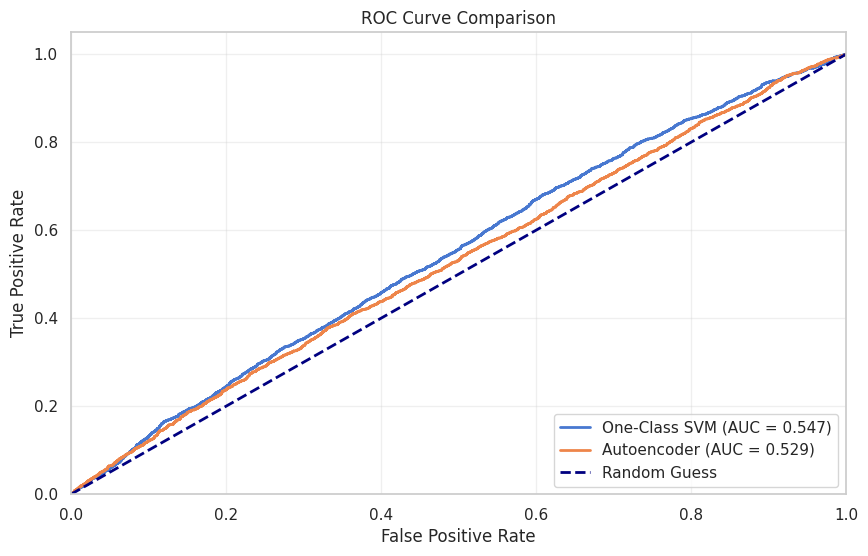

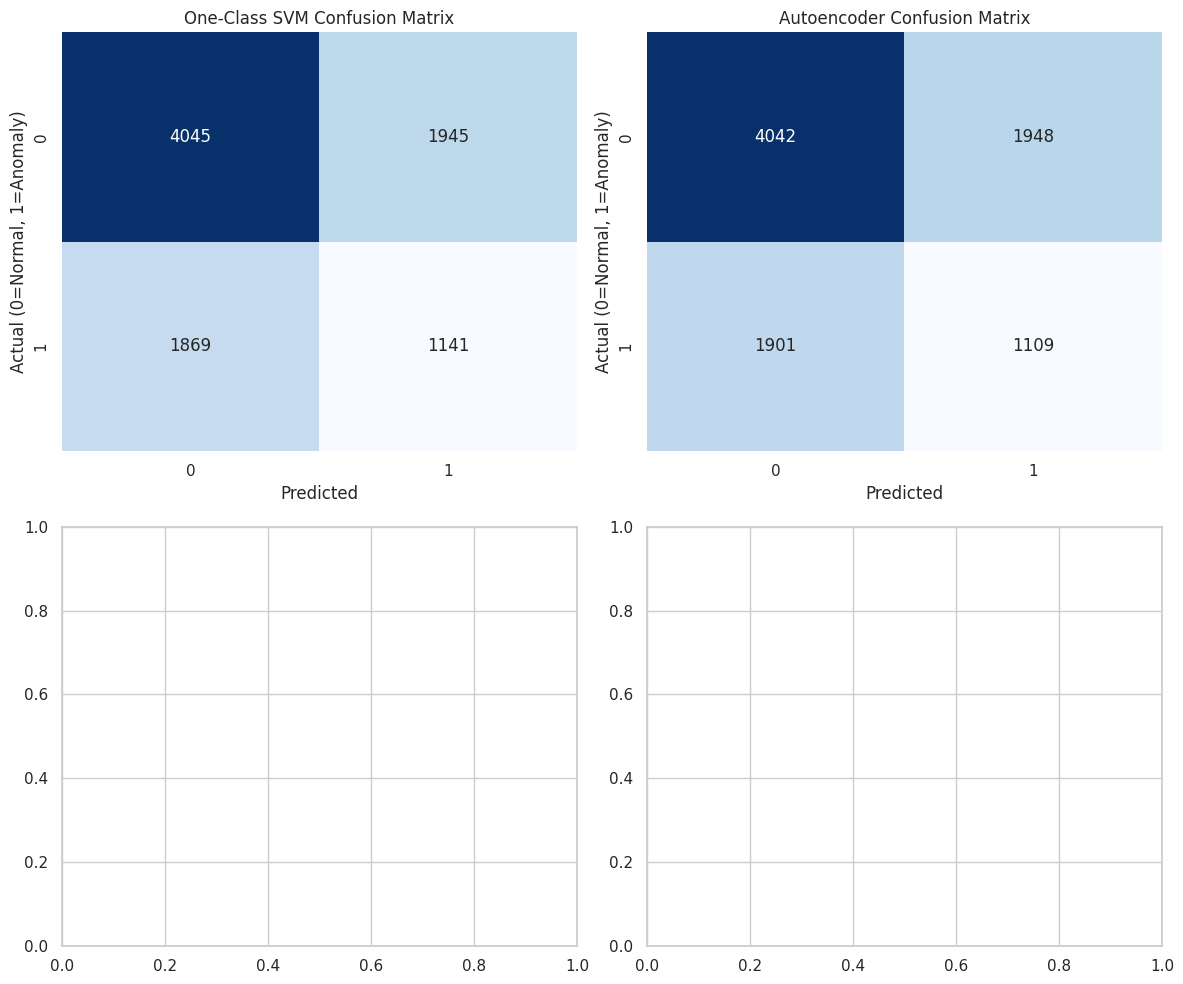

In [39]:
# 1. ROC Curves
plt.figure(figsize=(10, 6))
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, decision_scores[name])
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {results[name]["ROC-AUC"]:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 2. Confusion Matrices Grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, name in enumerate(results.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_ylabel('Actual (0=Normal, 1=Anomaly)')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 10. Real-Time Anomaly Detection Timeline Plots
Visualizing exactly how the best performing models respond to anomalies like RPM spikes or coolant temperature drift over the time-series testing data.

'Isolation Forest' not found in results. Automatically switching to 'One-Class SVM'.
If you want to see Isolation Forest, please scroll up and run the Step 4 cell first!


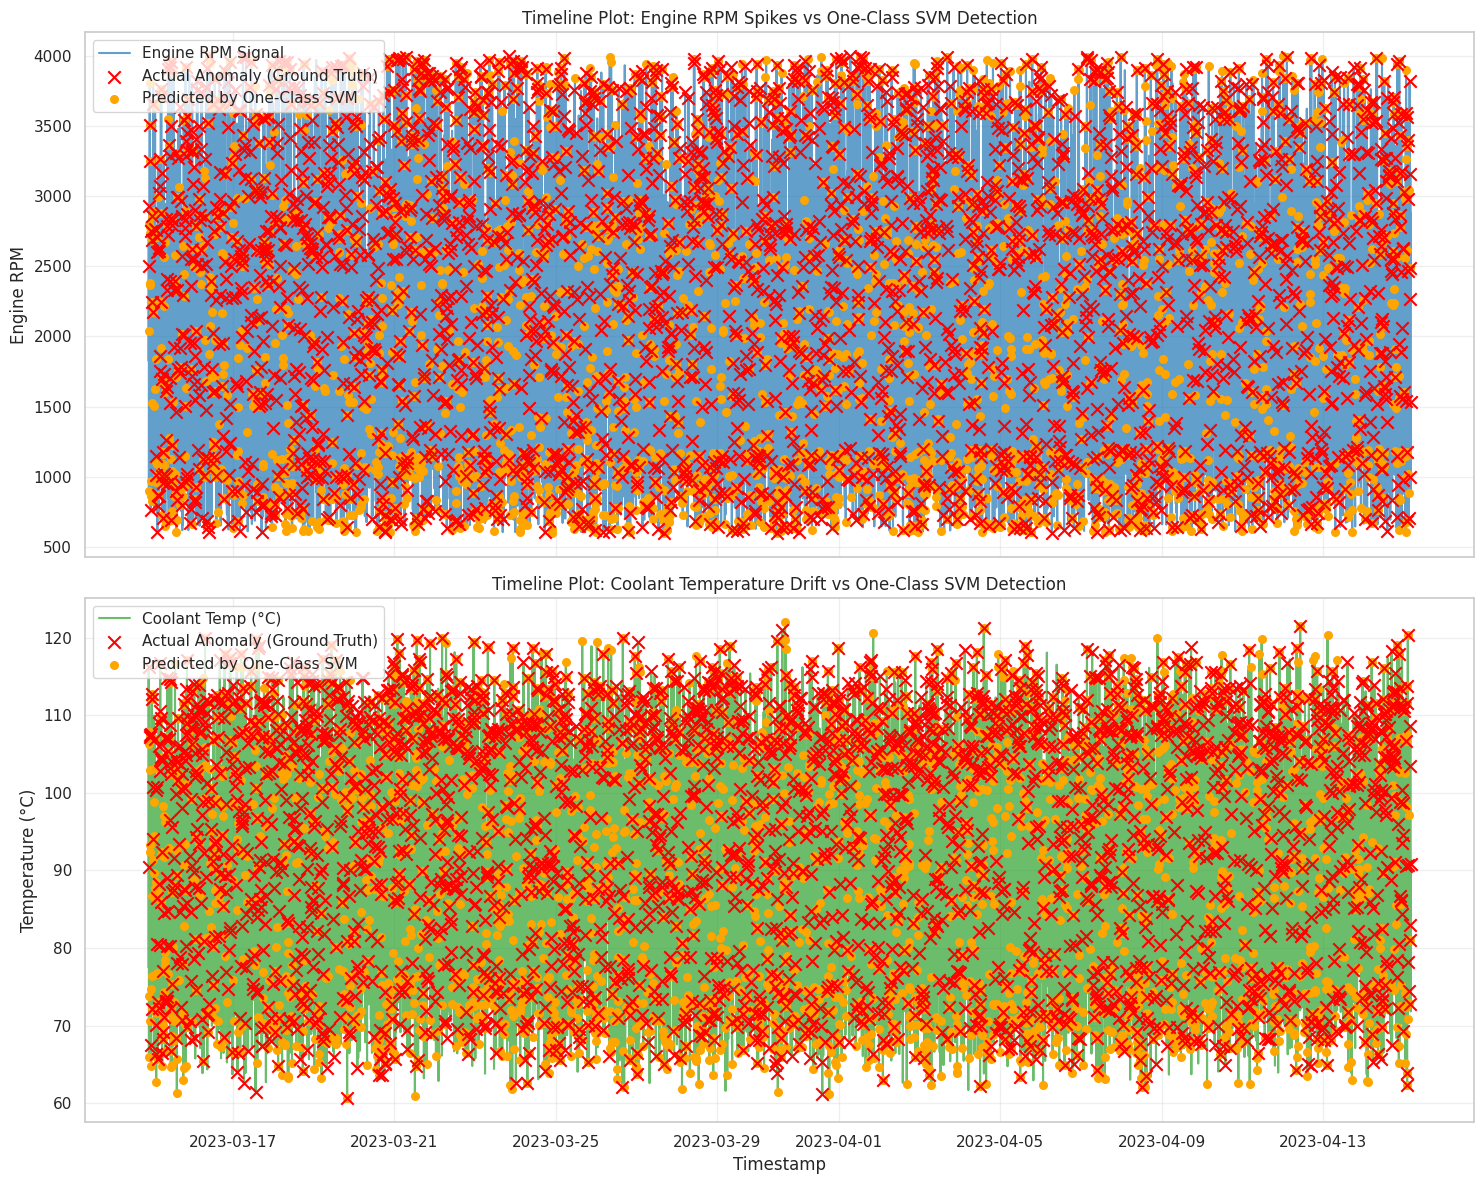

In [40]:
# Select the target model to visualize
target_model = "Isolation Forest"

# Safety check: If Isolation Forest wasn't run, pick the first available model
if target_model not in predictions:
    available_models = list(predictions.keys())
    if len(available_models) == 0:
        raise ValueError("No models have been trained yet! Please run at least one model cell (Steps 4-7).")

    print(f"'{target_model}' not found in results. Automatically switching to '{available_models[0]}'.")
    print("If you want to see Isolation Forest, please scroll up and run the Step 4 cell first!")
    target_model = available_models[0]

plot_df = pd.DataFrame({
    'Timestamp': test_timestamps,
    'Engine_RPM': X_test['engine_rpm'].values,
    'Coolant_Temp': X_test['coolant_temp_c'].values,
    'Actual_Anomaly': y_test.values,
    'Predicted_Anomaly': predictions[target_model]
})

fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Plot 1: Engine RPM Spikes
ax[0].plot(plot_df['Timestamp'], plot_df['Engine_RPM'], color='#1f77b4', label='Engine RPM Signal', alpha=0.7)
ax[0].scatter(plot_df[plot_df['Actual_Anomaly'] == 1]['Timestamp'],
              plot_df[plot_df['Actual_Anomaly'] == 1]['Engine_RPM'],
              color='red', label='Actual Anomaly (Ground Truth)', s=80, marker='x', zorder=5)
ax[0].scatter(plot_df[plot_df['Predicted_Anomaly'] == 1]['Timestamp'],
              plot_df[plot_df['Predicted_Anomaly'] == 1]['Engine_RPM'],
              color='orange', label=f'Predicted by {target_model}', s=30, marker='o', zorder=4)
ax[0].set_title(f'Timeline Plot: Engine RPM Spikes vs {target_model} Detection')
ax[0].set_ylabel('Engine RPM')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Plot 2: Coolant Temperature Drift
ax[1].plot(plot_df['Timestamp'], plot_df['Coolant_Temp'], color='#2ca02c', label='Coolant Temp (°C)', alpha=0.7)
ax[1].scatter(plot_df[plot_df['Actual_Anomaly'] == 1]['Timestamp'],
              plot_df[plot_df['Actual_Anomaly'] == 1]['Coolant_Temp'],
              color='red', label='Actual Anomaly (Ground Truth)', s=80, marker='x', zorder=5)
ax[1].scatter(plot_df[plot_df['Predicted_Anomaly'] == 1]['Timestamp'],
              plot_df[plot_df['Predicted_Anomaly'] == 1]['Coolant_Temp'],
              color='orange', label=f'Predicted by {target_model}', s=30, marker='o', zorder=4)
ax[1].set_title(f'Timeline Plot: Coolant Temperature Drift vs {target_model} Detection')
ax[1].set_xlabel('Timestamp')
ax[1].set_ylabel('Temperature (°C)')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()